# 20 - K-Means Cluster Visualization

Visualize clusters formed by the K-Means algorithm on a 2-feature CSV dataset.

**Problem Statement**

Given a CSV with two numeric features, apply K-Means and produce clear visualizations showing clusters, centroids and decision regions.

**What this notebook contains**

- Data generation (sample CSV) to simulate exam input
- Data cleaning, scaling, and simple EDA
- K-Means fitting and cluster visualizations (scatter + centroids + decision regions)
- Evaluation (inertia, silhouette) and notes for replacing the CSV in exam conditions

In [1]:
# Simple, clear implementation with comments explaining each step
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Generate and save a sample CSV (two features: x1, x2). In exam, replace this file with provided CSV.
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=0, n_features=2)
df = pd.DataFrame(X, columns=['x1','x2'])
df.to_csv('kmeans_viz_sample.csv', index=False)
print('Sample CSV saved: kmeans_viz_sample.csv')

Sample CSV saved: kmeans_viz_sample.csv


In [2]:
# === Load CSV and quick cleaning ===
data = pd.read_csv('kmeans_viz_sample.csv')
# If CSV columns differ, rename them: e.g., data.columns = ['x1','x2']
print('Shape:', data.shape)
print('Missing values:', data.isnull().sum())
data = data.dropna().reset_index(drop=True)
data.head()

Shape: (300, 2)
Missing values: x1    0
x2    0
dtype: int64


,x1,x2
0,0.063448,5.420804
1,1.329670,-0.485700
2,1.737308,4.425462
3,-1.612835,3.112175
4,-1.746445,1.833846


               x1          x2
count  300.000000  300.000000
mean     0.387710    2.676680
std      1.806727    1.781110
min     -3.896491   -1.874929
25%     -0.948666    1.251689
50%      0.567872    2.824013
75%      1.751903    4.092157
max      4.359184    6.254563


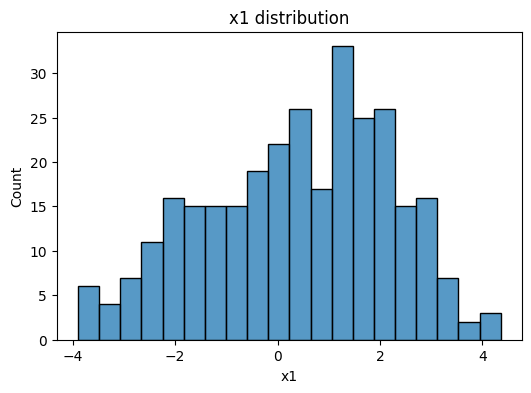

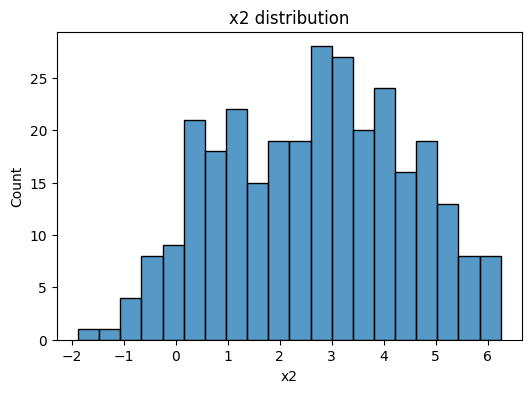

In [3]:
# === Explain data (simple stats) ===
print(data.describe())
plt.figure(figsize=(6,4))
sns.histplot(data['x1'], kde=False, bins=20)
plt.title('x1 distribution')
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(data['x2'], kde=False, bins=20)
plt.title('x2 distribution')
plt.show()

In [4]:
# === Feature scaling (keep it simple) ===
scaler = StandardScaler()
Xs = scaler.fit_transform(data[['x1','x2']])
Xs = pd.DataFrame(Xs, columns=['x1_s','x2_s'])
Xs.head()

,x1_s,x2_s
0,-0.179775,1.543256
1,0.522234,-1.778478
2,0.748233,0.983490
3,-1.109126,0.244916
4,-1.183201,-0.473998


In [5]:
# === Fit KMeans (choose k; in exam use elbow/silhouette to pick k) ===
k = 3  # chosen for this sample dataset
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
labels = kmeans.fit_predict(Xs)
centers = kmeans.cluster_centers_
inertia = kmeans.inertia_
sil = silhouette_score(Xs, labels)
print('k:', k)
print('Inertia:', inertia)
print('Silhouette score:', sil)

k: 3
Inertia: 167.0665662219138
Silhouette score: 0.4844986240526772


C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Lib\subprocess.py", line 1036, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

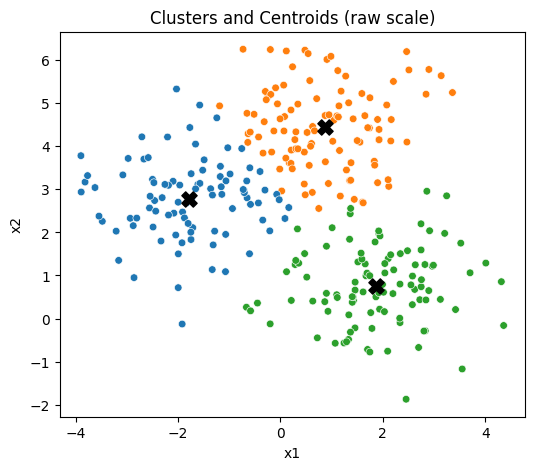

In [6]:
# === Visualization 1: Scatter with cluster colors and centroids (raw scale) ===
plt.figure(figsize=(6,5))
palette = sns.color_palette('tab10', k)
sns.scatterplot(x=data['x1'], y=data['x2'], hue=labels, palette=palette, legend=False, s=30)
centers_orig = scaler.inverse_transform(centers)  # map centroids back to raw scale
plt.scatter(centers_orig[:,0], centers_orig[:,1], c='black', s=120, marker='X')
plt.title('Clusters and Centroids (raw scale)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

C:\Users\paritosh\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


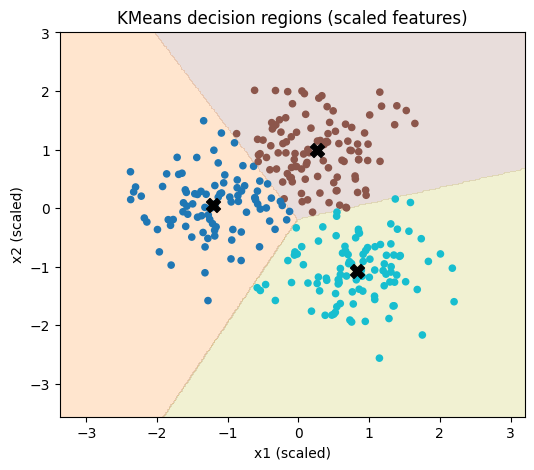

In [7]:
# === Visualization 2: Decision regions in feature space (using scaled grid) ===
# Create a mesh in scaled feature space, predict cluster for each point, and plot background colors.
xx, yy = np.meshgrid(np.linspace(Xs['x1_s'].min()-1, Xs['x1_s'].max()+1, 300),
                     np.linspace(Xs['x2_s'].min()-1, Xs['x2_s'].max()+1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
# plot decision regions (alpha for subtlety)
plt.contourf(xx, yy, Z, alpha=0.2, levels=np.arange(-0.5, k+0.5, 1), cmap='tab10')
# plot points (in scaled space for alignment with grid)
plt.scatter(Xs['x1_s'], Xs['x2_s'], c=labels, s=20, cmap='tab10')
# plot centroids in scaled space
plt.scatter(centers[:,0], centers[:,1], c='black', s=100, marker='X')
plt.title('KMeans decision regions (scaled features)')
plt.xlabel('x1 (scaled)')
plt.ylabel('x2 (scaled)')
plt.show()

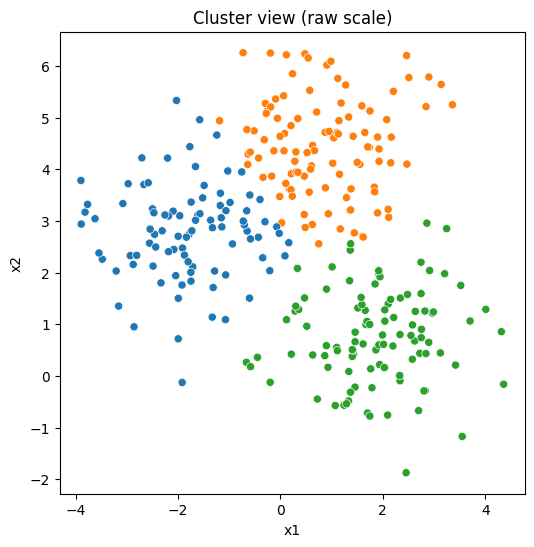

In [8]:
# === Visualization 3: Pairplot-like view (small) ===
plt.figure(figsize=(6,6))
sns.scatterplot(x=data['x1'], y=data['x2'], hue=labels, palette=palette, legend=False, s=35)
plt.title('Cluster view (raw scale)')
plt.show()

In [9]:
# === Save results and short summary ===
out = data.copy()
out['cluster'] = labels
out.to_csv('kmeans_viz_clusters.csv', index=False)
print('Saved clustered data to kmeans_viz_clusters.csv')
print('Summary: k=', k, 'inertia=', inertia, 'silhouette=', sil)

Saved clustered data to kmeans_viz_clusters.csv
Summary: k= 3 inertia= 167.0665662219138 silhouette= 0.4844986240526772


**Notes for exams / different CSVs**

- Replace `pd.read_csv('kmeans_viz_sample.csv')` with the provided filename.
- If column names differ, rename columns to two numeric names: `data.columns = ['x1','x2']`.
- If CSV contains more features but you only want two, select the two numeric columns you want to visualize.
- If there are categorical columns, drop or encode them before scaling/clustering.
- To choose `k`, use the elbow/silhouette check (simple loop over candidate k values).

**Pseudocode (brief)**



Load CSV -> Clean -> Scale -> Fit KMeans -> Plot scatter + centroids -> Plot decision regions -> Save clusters

